# Generate README Images

Notebook ini membuat 4 gambar untuk README:
1. `pipeline_overview.png`
2. `preprocessing_stages.png`
3. `confusion_matrix.png`
4. `sample_predictions_table.png`

Output disimpan ke `docs/images/`.

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from skimage.feature import local_binary_pattern
from sklearn.metrics import confusion_matrix

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

# Resolve project root robustly from notebook location
if "__file__" in globals():
    project_root = Path(__file__).resolve().parents[1]
else:
    project_root = Path.cwd()

if (project_root / "docs" / "generate_readme_images.ipynb").exists() is False:
    # If notebook is run from docs/ in Jupyter, cwd can be docs/
    if (project_root.parent / "docs" / "generate_readme_images.ipynb").exists():
        project_root = project_root.parent

images_dir = project_root / "docs" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

dataset_root = project_root / "data" / "sdfvd2.0"
pred_csv = project_root / "outputs" / "sdfvd2_best_v3" / "test_predictions.csv"

print(f"project_root: {project_root}")
print(f"images_dir:   {images_dir}")
print(f"pred_csv ok:  {pred_csv.exists()}")

project_root: c:\ai-video-lbp-svm
images_dir:   c:\ai-video-lbp-svm\docs\images
pred_csv ok:  True


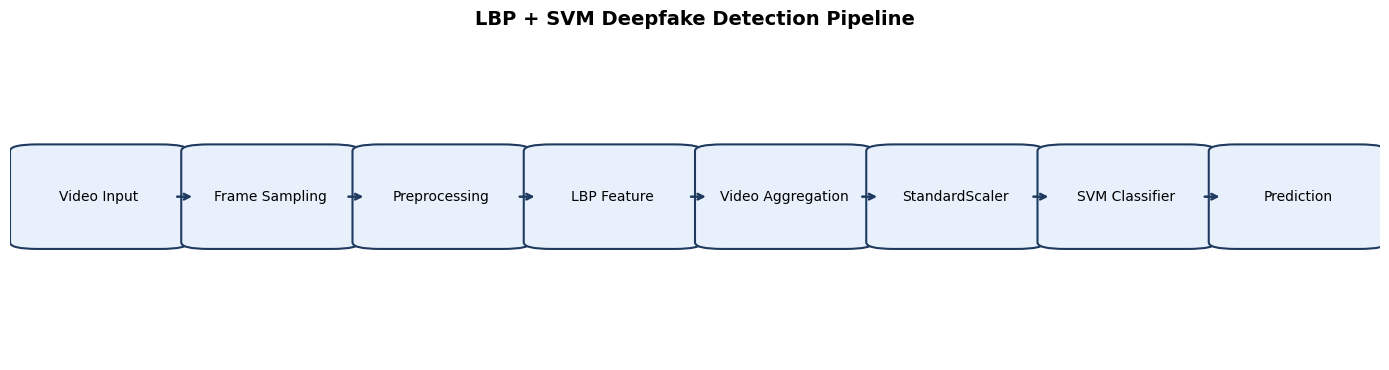

Saved: c:\ai-video-lbp-svm\docs\images\pipeline_overview.png


In [2]:
# 1) pipeline_overview.png
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis("off")

steps = [
    "Video Input",
    "Frame Sampling",
    "Preprocessing",
    "LBP Feature",
    "Video Aggregation",
    "StandardScaler",
    "SVM Classifier",
    "Prediction"
]

x0 = 0.01
box_w = 0.11
gap = 0.015
y = 0.35
h = 0.3

for i, text in enumerate(steps):
    x = x0 + i * (box_w + gap)
    box = FancyBboxPatch(
        (x, y), box_w, h,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=1.5, edgecolor="#1f3a5f", facecolor="#e8f1fb"
    )
    ax.add_patch(box)
    ax.text(x + box_w / 2, y + h / 2, text, ha="center", va="center", fontsize=10)

    if i < len(steps) - 1:
        x_arrow_start = x + box_w
        x_arrow_end = x + box_w + gap
        ax.annotate(
            "",
            xy=(x_arrow_end, y + h / 2),
            xytext=(x_arrow_start, y + h / 2),
            arrowprops=dict(arrowstyle="->", lw=1.8, color="#1f3a5f")
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("LBP + SVM Deepfake Detection Pipeline", fontsize=14, weight="bold")

out_path = images_dir / "pipeline_overview.png"
fig.tight_layout()
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

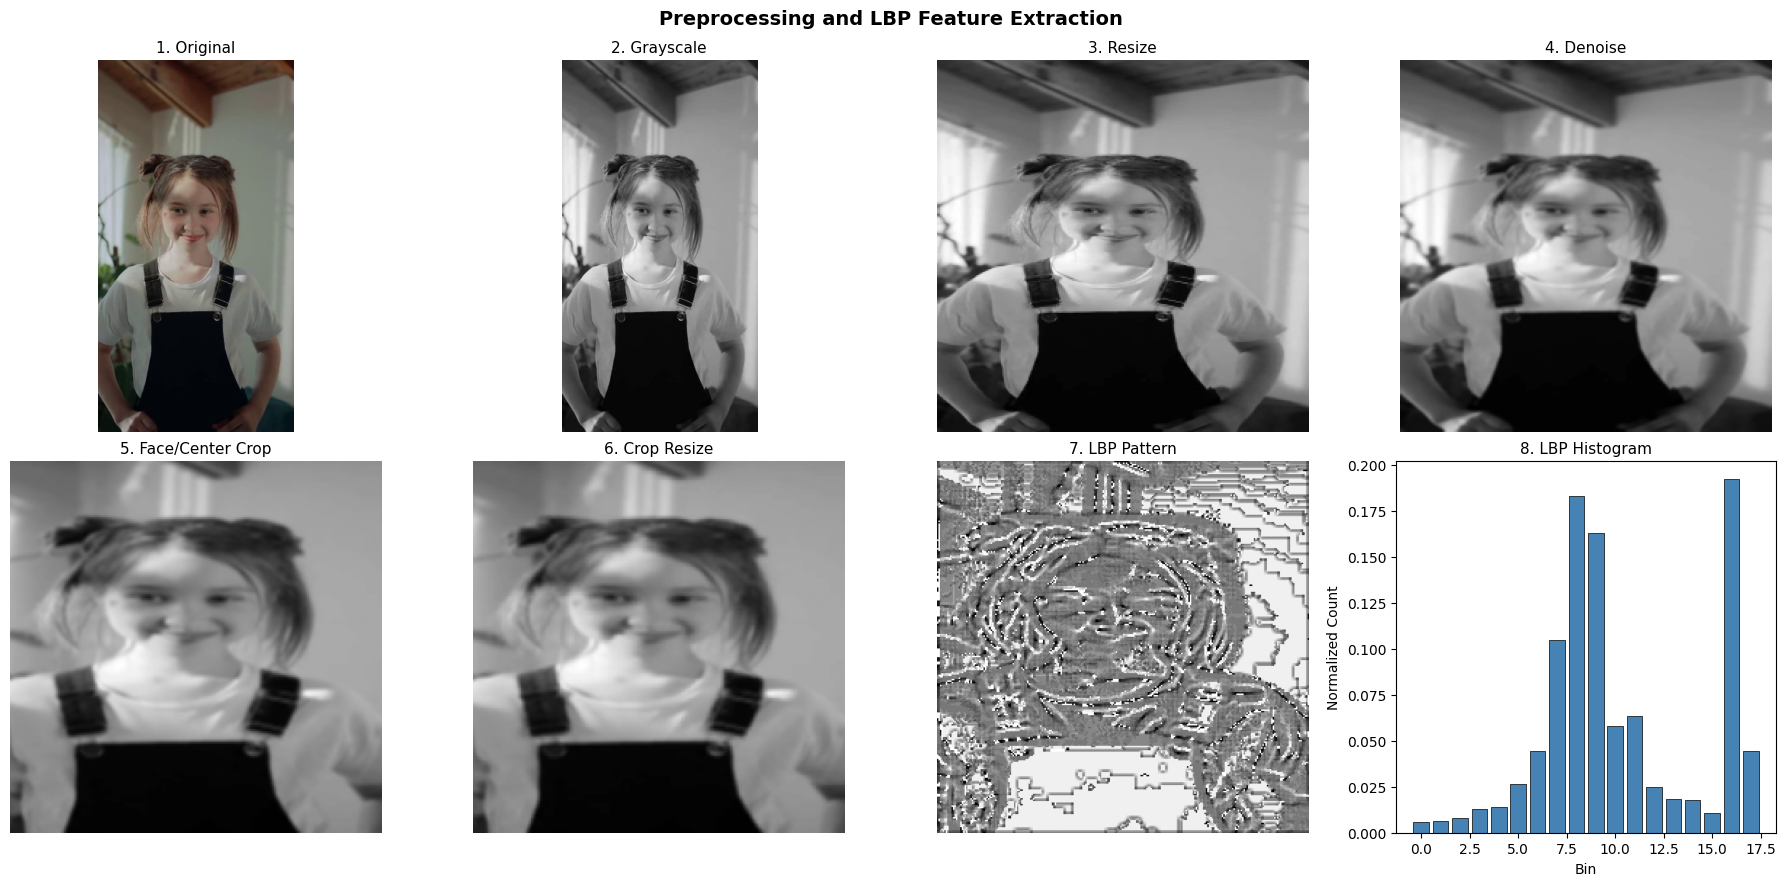

Saved: c:\ai-video-lbp-svm\docs\images\preprocessing_stages.png
Source video: real_v10_aug_0.mp4


In [3]:
# 2) preprocessing_stages.png
# Try import helper from project source
import sys
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.features import crop_face_or_center

def pick_one_video(root: Path):
    exts = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".flv"}
    if not root.exists():
        return None
    for cls in ["real", "not_real"]:
        cls_dir = root / cls
        if cls_dir.exists():
            vids = sorted([p for p in cls_dir.iterdir() if p.is_file() and p.suffix.lower() in exts])
            if vids:
                return vids[0]
    return None

def read_mid_frame(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    mid = total // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)
    ret, frame = cap.read()
    cap.release()
    if not ret or frame is None:
        return None
    return frame

video = pick_one_video(dataset_root)
frame_bgr = read_mid_frame(video) if video else None

if frame_bgr is None:
    # Fallback synthetic image so notebook still generates figure
    x = np.linspace(0, 255, 256, dtype=np.uint8)
    frame_gray = np.tile(x, (256, 1))
    frame_rgb = cv2.cvtColor(frame_gray, cv2.COLOR_GRAY2RGB)
else:
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

img_size = 256
lbp_points = 16
lbp_radius = 2
lbp_method = "uniform"

gray = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2GRAY)
gray_resized = cv2.resize(gray, (img_size, img_size), interpolation=cv2.INTER_AREA)
gray_denoised = cv2.GaussianBlur(gray_resized, (3, 3), 0)
face_cropped = crop_face_or_center(gray_denoised, margin=0.25)
face_resized = cv2.resize(face_cropped, (img_size, img_size), interpolation=cv2.INTER_AREA)
lbp_img = local_binary_pattern(face_resized, lbp_points, lbp_radius, method=lbp_method)

n_bins = lbp_points + 2
lbp_hist, _ = np.histogram(lbp_img.ravel(), bins=n_bins, range=(0, n_bins))
lbp_hist = lbp_hist.astype(np.float32)
lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-8)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Preprocessing and LBP Feature Extraction", fontsize=14, fontweight="bold")

steps = [
    (frame_rgb, "1. Original", None),
    (gray, "2. Grayscale", "gray"),
    (gray_resized, "3. Resize", "gray"),
    (gray_denoised, "4. Denoise", "gray"),
    (face_cropped, "5. Face/Center Crop", "gray"),
    (face_resized, "6. Crop Resize", "gray"),
    (lbp_img, "7. LBP Pattern", "gray"),
]

for idx, (img, title, cmap) in enumerate(steps):
    ax = axes[idx // 4][idx % 4]
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

ax_hist = axes[1][3]
ax_hist.bar(range(n_bins), lbp_hist, color="steelblue", edgecolor="black", linewidth=0.5)
ax_hist.set_title("8. LBP Histogram", fontsize=11)
ax_hist.set_xlabel("Bin")
ax_hist.set_ylabel("Normalized Count")

fig.tight_layout()
out_path = images_dir / "preprocessing_stages.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
if video:
    print(f"Source video: {video.name}")
else:
    print("Source video: fallback synthetic image (dataset not found/readable)")

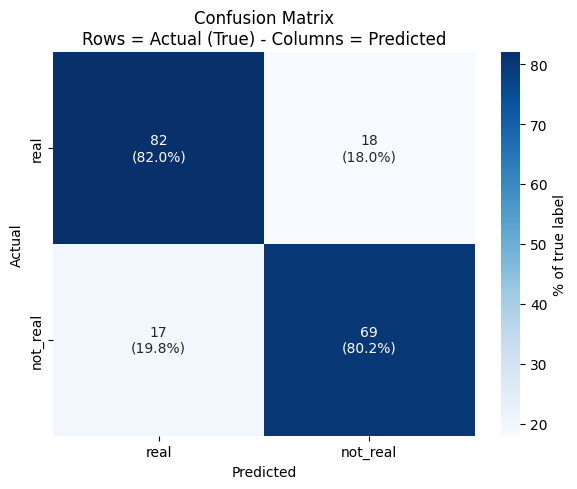

Saved: c:\ai-video-lbp-svm\docs\images\confusion_matrix.png


In [4]:
# 3) confusion_matrix.png from test_predictions.csv
if not pred_csv.exists():
    raise FileNotFoundError(f"File not found: {pred_csv}")

df_pred = pd.read_csv(pred_csv)
required_cols = {"y_true", "y_pred"}
if not required_cols.issubset(df_pred.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}. Found: {list(df_pred.columns)}")

labels = ["real", "not_real"]
cm = confusion_matrix(df_pred["y_true"], df_pred["y_pred"], labels=labels)
cm_perc = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100.0

annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_perc[i, j]:.1f}%)"

fig, ax = plt.subplots(figsize=(6, 5))
if HAS_SEABORN:
    sns.heatmap(
        cm_perc,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "% of true label"},
        ax=ax,
    )
else:
    im = ax.imshow(cm_perc, interpolation="nearest", cmap="Blues")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt_color = "white" if cm_perc[i, j] > 50 else "black"
            ax.text(j, i, annot[i, j], ha="center", va="center", color=txt_color)
    fig.colorbar(im, ax=ax, label="% of true label")

ax.set_title("Confusion Matrix\nRows = Actual (True) - Columns = Predicted")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
fig.tight_layout()

out_path = images_dir / "confusion_matrix.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

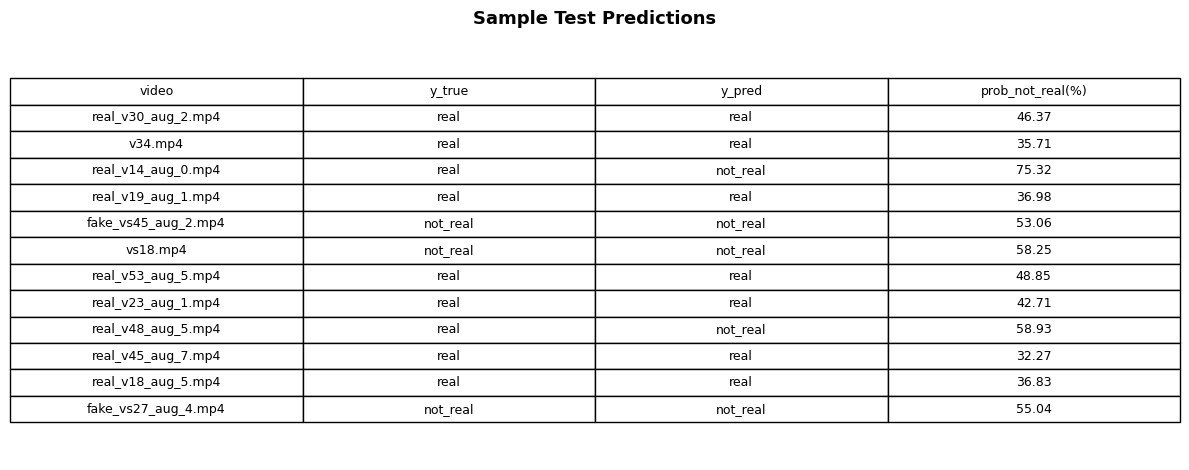

Saved: c:\ai-video-lbp-svm\docs\images\sample_predictions_table.png


In [5]:
# 4) sample_predictions_table.png
df_show = df_pred.copy()

if "video_path" in df_show.columns:
    df_show["video"] = df_show["video_path"].astype(str).map(lambda p: Path(p).name)
else:
    df_show["video"] = [f"sample_{i+1}" for i in range(len(df_show))]

cols = ["video", "y_true", "y_pred"]
if "prob_not_real" in df_show.columns:
    df_show["prob_not_real"] = (df_show["prob_not_real"].astype(float) * 100.0).round(2)
    cols.append("prob_not_real")

df_small = df_show[cols].head(12).copy()
if "prob_not_real" in df_small.columns:
    df_small = df_small.rename(columns={"prob_not_real": "prob_not_real(%)"})

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")
tbl = ax.table(
    cellText=df_small.values,
    colLabels=df_small.columns,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
ax.set_title("Sample Test Predictions", fontsize=13, weight="bold", pad=12)

out_path = images_dir / "sample_predictions_table.png"
fig.tight_layout()
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Next

Setelah semua sel sukses dijalankan, cek folder `docs/images/` lalu masukkan gambar ke README:

```markdown
![Pipeline](docs/images/pipeline_overview.png)
![Preprocessing](docs/images/preprocessing_stages.png)
![Confusion Matrix](docs/images/confusion_matrix.png)
![Sample Predictions](docs/images/sample_predictions_table.png)
```